In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [25]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [26]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_2.txt', sep='\\s+')
df1

,time,v(vi),v(vo)
0,1.900000e-09,0.657402,0.633422
1,3.900000e-09,0.715501,0.692723
2,5.900000e-09,0.768871,0.748240
3,7.900000e-09,0.815328,0.797695
4,9.900000e-09,0.852969,0.839057
...,...,...,...
535,6.390000e-08,0.675284,0.897195
536,6.590000e-08,0.495717,0.301090
537,6.790000e-08,0.732200,0.897176
538,6.990000e-08,0.441228,0.306845


In [27]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [28]:
vi = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo = np.reshape(df1['v(vo)'].values, [runs, len(df1)//runs])

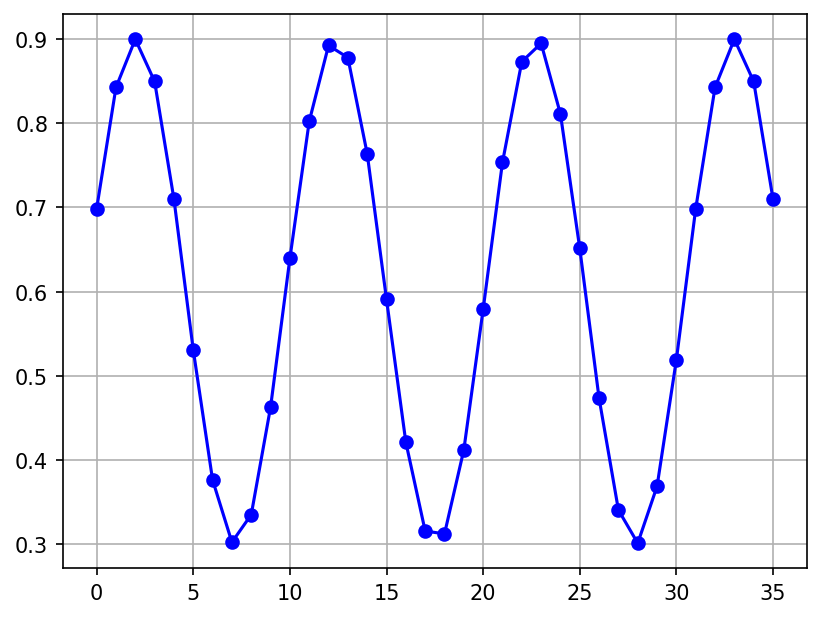

In [29]:
plt.plot(vo[2, :], "b-o")
plt.grid()
plt.show()

In [30]:
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

-2.0973159068403915e-08
-2.1781125832005625e-08
3.9015066344546285e-08
0.0
-1.4635007165805916e-07
-2.539469409561025e-07
-4.769622637425407e-07
6.17591634873523e-08
9.256929975311436e-07
5.465408912184115e-07
1.4213363042945872e-08
-1.0748557098034756e-06
-1.9343550466543764e-06
-7.980152612399028e-06
-1.0688351796658067e-06
-3.2231704354019204e-06
3.373566880362596e-06
-1.945878630226625e-06
3.3562210109224065e-06
1.6457668541584259e-06
-1.4142587834345678e-05
-3.8664536395544146e-05
-2.7514305660746864e-05
1.874674001898948e-05
-3.8398826636594964e-05
-6.249759860258779e-07
-1.3751824991163923e-05
-6.076241272390619e-06
1.1957943924852248e-05
9.030626216806452e-07


In [ ]:
# Analysis
vdd = 1.2
vt = 0.47
cpss = 0
cpls = 55e-15
cb = 830e-15
cpss = cb/10
vgs = vdd*cb/(cb+cpls)
vov = vgs - vt
print(vov)
vm = 0.3
fs = 500e6
fin = bins*fs/ndft
fbw= 6.6e9
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cpss/cb+0.11)**2)
print(fbw/1e6)

0.6546485473289596
6600.0


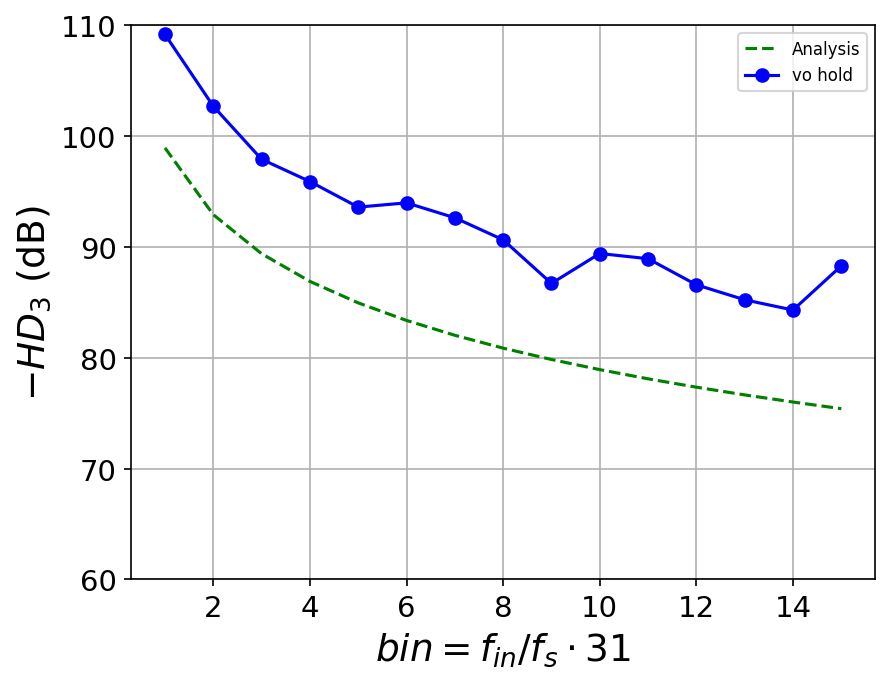

In [32]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_calc, "g--", label='Analysis')
#plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo, "b-o", label='vo hold')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(60, 110)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

-3.2231704354019204e-06
3.373566880362596e-06
-1.945878630226625e-06
3.3562210109224065e-06
1.6457668541584259e-06
-1.4142587834345678e-05
-3.8664536395544146e-05
-2.7514305660746864e-05
1.874674001898948e-05
-3.8398826636594964e-05
-6.249759860258779e-07
-1.3751824991163923e-05
-6.076241272390619e-06
1.1957943924852248e-05
9.030626216806452e-07


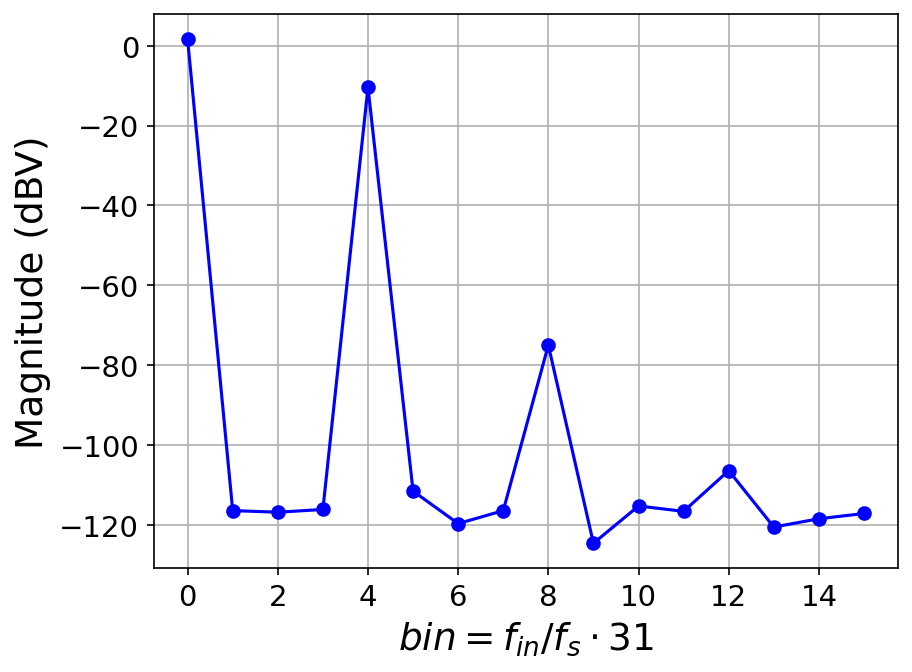

In [33]:
spec_dbv_out = compute_spectra(bins, vo, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o")
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.show()
